(imputation)=

# Smooth sparse expression with graph diffusion

A zero RNA count can mean that a gene was not expressed or that its transcripts were
not captured. Graph diffusion borrows signal from neighboring cells to make regional
patterns easier to see. It creates a weighted average, not a new measurement.

Here we smooth CD4 expression in a prepared PBMC analysis. CD4 is useful for this
comparison because its RNA signal can be sparse, and it occurs in both T cells and
monocytes. Use other markers to interpret its location, as described in [](annotation.ipynb).

## Open the prepared graph

In [1]:
# Open count stores and run CyteArc analyses.
import cytearc

# Select explicit fields and display options for plots.
from cytearc.plotting import CellField, ColorScale, FeatureRef

# Keep routine logs and progress bars out of the results.
cytearc.configure_output(level="WARNING", progress=False)

# Download the prepared example store.
dataset = cytearc.cytebase.connect("cytearc_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="cytearc_datasets",
    zarr=True,
)

# Open the count store for this analysis.
ds = cytearc.DataStore(f"{dataset}/data.zarr", nthreads=4)

# Open the saved analysis and its exact results.
run = ds.pipeline.open(label="docs_default")

# Keep the graph from the saved analysis.
graph = run["connectivity_map"]

# Inspect the opened store's cells and features.
ds

DataStore has 3948 (5025) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_G2M_score', 'RNA_S_score', 
            'RNA_UMAP1', 'RNA_UMAP2', 'RNA_cell_cycle_phase', 'RNA_clusters', 'RNA_doublet_score', 
            'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_paris_cluster', 'RNA_percentMito', 
            'RNA_percentRibo'
   RNA assay has 33538 features and following metadata:
            'I', 'ids', 'names', 'dropOuts', 'feature_type', 
            'genome', 'nCells'

Started: 2026-10-08T11:03:24.343171Z | Wall time: 12.406 s

The graph and UMAP come from the same saved analysis. First view its clusters so we
have population boundaries to compare with the expression maps.

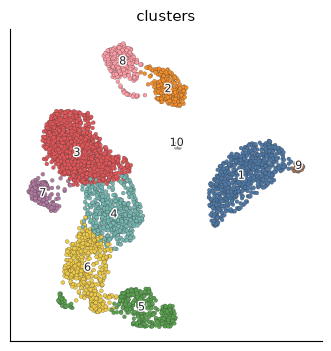

Started: 2026-10-08T11:03:36.753466Z | Wall time: 1.861 s

In [2]:
# Locate the PBMC clusters before comparing CD4 expression.
ds.plots.embedding(run=run, layout="umap", color_by="clusters", legend_loc="on_data")

## Start with the default smoothing

`imputation.diffusion` defaults to two diffusion steps (`t=2`). Each step spreads
signal across graph neighbors. `imputation.compute_imputed` applies that operator to one feature.

In [3]:
# Build the diffusion operator with the default two steps.
diffusion = ds.imputation.diffusion(graph)

# Apply diffusion to normalized CD4 expression.
smoothed = ds.imputation.compute_imputed(feature_name="CD4", diffusion=diffusion)

# Save the calculated values in the cell table.
ds.cells.insert("CD4_imputed_t2", smoothed, key="I", overwrite=True)

# Check the number of smoothed cells and their expression range.
{
    "cells": len(smoothed),
    "minimum": round(float(smoothed.min()), 4),
    "maximum": round(float(smoothed.max()), 4),
}

{'cells': 3948, 'minimum': 0.0, 'maximum': 0.3034}

Started: 2026-10-08T11:03:38.619122Z | Wall time: 1.767 s

The inserted column lets us plot the smoothed values beside observed, normalized CD4
expression. Both panels share a color scale. In this prepared store, the active cells
(`I`) match the saved graph's cell selection.

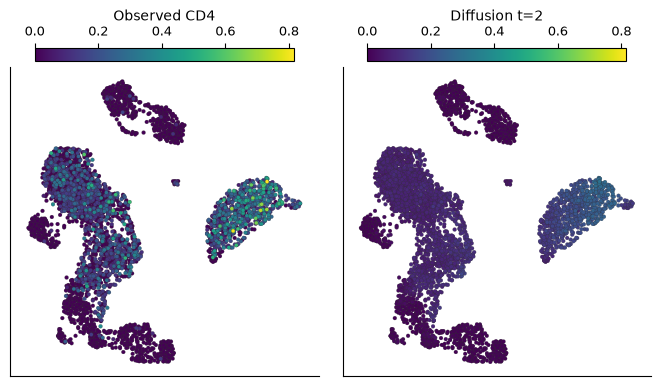

Started: 2026-10-08T11:03:40.389259Z | Wall time: 1.027 s

In [4]:
# Compare observed CD4 with two-step smoothing on a shared color scale.
ds.plots.embedding(
    layout=run["umap"],
    color_by=[
        FeatureRef("CD4", label="Observed CD4"),
        CellField("CD4_imputed_t2", kind="continuous", label="Diffusion t=2"),
    ],
    n_columns=2,
    color_scale=ColorScale(scope="shared"),
    sort_values=True,
)

Look for smoother signal within regions that already express CD4. Then check whether
signal extends into unrelated populations. A filled gap does not mean that CD4 was
detected in that cell, and a smoother map is not automatically more accurate.

## Explore the effect of diffusion depth

A larger `t` lets signal travel through more graph steps. To judge whether the default
smooths too little or too much, compare it with one and three steps:

In [5]:
# Compute the two additional diffusion depths.
for t in (1, 3):

    # Build the operator for this diffusion depth.
    operator = ds.imputation.diffusion(graph, t=t)

    # Smooth CD4 expression with this operator.
    values = ds.imputation.compute_imputed(feature_name="CD4", diffusion=operator)

    # Save the calculated values in the cell table.
    ds.cells.insert(f"CD4_imputed_t{t}", values, key="I", overwrite=True)

# Confirm which smoothing depths are ready to compare.
{"diffusion steps": [1, 2, 3], "cells per column": len(values)}

{'diffusion steps': [1, 2, 3], 'cells per column': 3948}

Started: 2026-10-08T11:03:41.419680Z | Wall time: 1.968 s

Place the observed values beside all three smoothing depths:

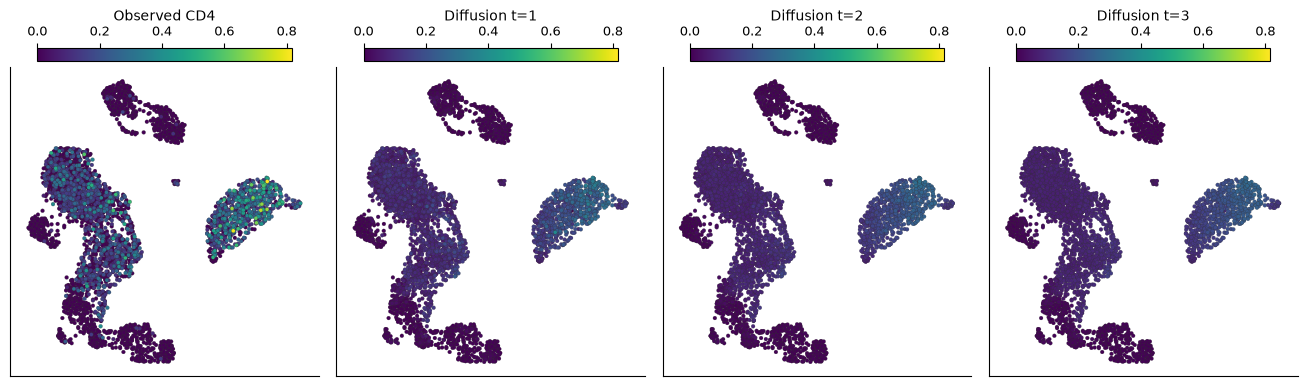

Started: 2026-10-08T11:03:43.393582Z | Wall time: 1.700 s

In [6]:
# Name the three smoothed columns for the comparison plot.
diffusion_fields = [
    CellField(f"CD4_imputed_t{t}", kind="continuous", label=f"Diffusion t={t}")
    for t in (1, 2, 3)
]

# Compare observed CD4 with all three diffusion depths.
ds.plots.embedding(
    layout=run["umap"],
    color_by=[FeatureRef("CD4", label="Observed CD4"), *diffusion_fields],
    n_columns=4,
    color_scale=ColorScale(scope="shared"),
    sort_values=True,
)

The larger depths fill more of the patchy CD4 pattern in this example. Use the observed
panel and cluster map to judge where that added signal goes. Diffusion can blur a real
boundary if the graph connects cells from different populations. Revisit the graph in
[](graph_construction.ipynb) when none of these depths preserves the intended structure.

## Common mistakes and limitations
- Using smoothed values as statistical input: diffusion shares information between cells, so imputed values can inflate apparent certainty. Differential expression should use observed counts with an appropriate sample-level model.
- Reading smoothed co-expression as regulation: diffusion can strengthen apparent correlations between genes, which does not establish a regulatory relationship.
- Trusting a new gradient: doublets or graph edges that join unrelated populations can spread signal between them, so check both before interpreting a unexpected boundary.